In [150]:
import time

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import QuantileTransformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils.data as datutils
import utils.file as futils

import warnings
from pandas.errors import ParserWarning

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [123]:
# Load data
mah_dict = futils.get_mah_all()
ma, _, aexp_bins = datutils.interp_ma(mah_dict)
am, mass_bins = datutils.get_am(ma=ma, scales=aexp_bins,
                                min_mass_bin=0.01, log_spacing=True)
# for nans in am, want to use previous value
# but if first value is nan, set to 0 and propagate till we get a non-nan value
am[:, 0] = np.nan_to_num(am[:, 0], nan=0.0)
am = np.fmax.accumulate(am, axis=1)
stacked_ma = np.vstack([ma]*3)  # because we have 3 projections
stacked_am = np.vstack([am]*3)  # because we have 3 projections


m14 = pd.read_csv('data/gadgetx3k/mag_diff_GadgetX_3k.csv')
m14.set_index('ID', inplace=True)
m14 = m14.loc[mah_dict.keys()]
m14.reset_index(inplace=True)
proj_3d = m14['3d']
proj_x = m14['proj_x']
proj_y = m14['proj_y']
proj_z = m14['proj_z']
m14_stacked = np.hstack([proj_x, proj_y, proj_z])
m14_xyz = pd.concat([m14['proj_x'], m14['proj_y'], m14['proj_z']], axis=0)

dsdf = futils.get_ds()
dsdf = dsdf.loc[mah_dict.keys()]
dsdf.reset_index(inplace=True)
eta_200 = dsdf['eta_200[3]']
delta_200 = dsdf['delta_200[4]']
fm_200 = dsdf['fm_200[5]']
fm2_200 = dsdf['fm2_200[6]']

eta_500 = dsdf['eta_500[8]']
delta_500 = dsdf['delta_500[9]']
fm_500 = dsdf['fm_200[5]']
fm2_500 = dsdf['fm2_500[11]']

dsdf.drop(columns=['ID', 'eta_500[8]', 'delta_500[9]',
          'fm_500[10]', 'fm2_500[11]'], inplace=True)

sm_df_zx = futils.get_morphologies(
    'results/zx/rin50.0kpc_rout1.0Mpc_205.csv')
sm_df_xy = futils.get_morphologies(
    'results/xy/rin50.0kpc_rout1.0Mpc_205.csv')
sm_df_yz = futils.get_morphologies(
    'results/yz/rin50.0kpc_rout1.0Mpc_205.csv')

smdf = pd.concat([sm_df_xy, sm_df_yz, sm_df_zx])

conc = sm_df_zx['C']
asym = sm_df_zx['A']

df1 = futils.get_morphologies('results/xy/r_0.03Mpc_205.csv')
df2 = futils.get_morphologies('results/yz/r_0.03Mpc_205.csv')
df3 = futils.get_morphologies('results/zx/r_0.03Mpc_205.csv')

inner_df = pd.concat([df1, df2, df3])

iconc = inner_df['C']

/Users/kabelo/clusters/utils/data.py:342: RuntimeWarning: invalid value encountered in log
  np.log(_m_peaks), np.log(_scales), bounds_error=False, fill_value=np.nan


In [149]:
smdf.columns

Index(['rhalf_circ', 'C', 'A', 'sersic_amplitude'], dtype='object')

In [155]:
np.shape(stacked_am)

(615, 100)

In [ ]:
start = time.time()
state = 5

# x = np.vstack((smdf.to_numpy().T, m14_stacked, iconc.to_numpy())).T
n_halos = len(am)
halo_idx = np.arange(n_halos)
train_idx, test_idx = train_test_split(
    halo_idx, test_size=0.25, random_state=state)

# Stack indices across all 3 projections
stacked_train_idx = np.concatenate(
    [train_idx, train_idx + n_halos, train_idx + 2*n_halos])
stacked_test_idx = np.concatenate(
    [test_idx,  test_idx + n_halos, test_idx + 2*n_halos])

x_train = np.vstack([smdf_proj.to_numpy()[train_idx]
                    for smdf_proj in [sm_df_xy, sm_df_yz, sm_df_zx]])

x_train = np.concatenate([x_train, 
                          m14_stacked[:, None][stacked_train_idx],
                          iconc.to_numpy()[:, None][stacked_train_idx]], axis=1)

x_test = np.vstack([smdf_proj.to_numpy()[test_idx]
                   for smdf_proj in [sm_df_xy, sm_df_yz, sm_df_zx]])
x_test = np.concatenate([x_test,
                         m14_stacked[:, None][stacked_test_idx],
                         iconc.to_numpy()[:, None][stacked_test_idx]], axis=1)

y_train = stacked_am[stacked_train_idx]
y_test = stacked_am[stacked_test_idx]

mhalf_indx = np.argmin(np.abs(mass_bins-0.5))
a50_test = y_test[:, mhalf_indx]
a50_train = y_train[:, mhalf_indx]


qt = QuantileTransformer(output_distribution='normal', random_state=state)
x_train_qt = qt.fit_transform(x_train)
x_test_qt = qt.transform(x_test) # fit only on train

model = xgb.XGBRegressor(random_state=state)
parameter_space = {'learning_rate': [0.01, 0.05, 0.1],
                   'max_depth': [1, 2, 3],
                   'n_estimators': [100, 250, 500]}

reg = GridSearchCV(model, parameter_space, cv=5, scoring='r2', verbose=1)
reg.fit(x_train_qt, a50_train)
regressor = reg.best_estimator_

print(reg.best_params_)
print('  ... training took %.2f seconds' % (time.time() - start))
preds = regressor.predict(x_test_qt)
residuals = preds - a50_test
r2 = r2_score(a50_test, preds)
print(f'r2 : {r2}')
print(f'rmse : {np.sqrt(mean_squared_error(a50_test, preds))}')

/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (459). n_quantiles is set to n_samples.
  warnings.warn(


Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'seed': 5}
  ... training took 19.24 seconds
r2 : 0.2454428605174488
rmse : 0.0967707394166281
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'seed': 5}
  ... training took 19.24 seconds
r2 : 0.2454428605174488
rmse : 0.0967707394166281


In [167]:
np.shape(iconc)

(615,)

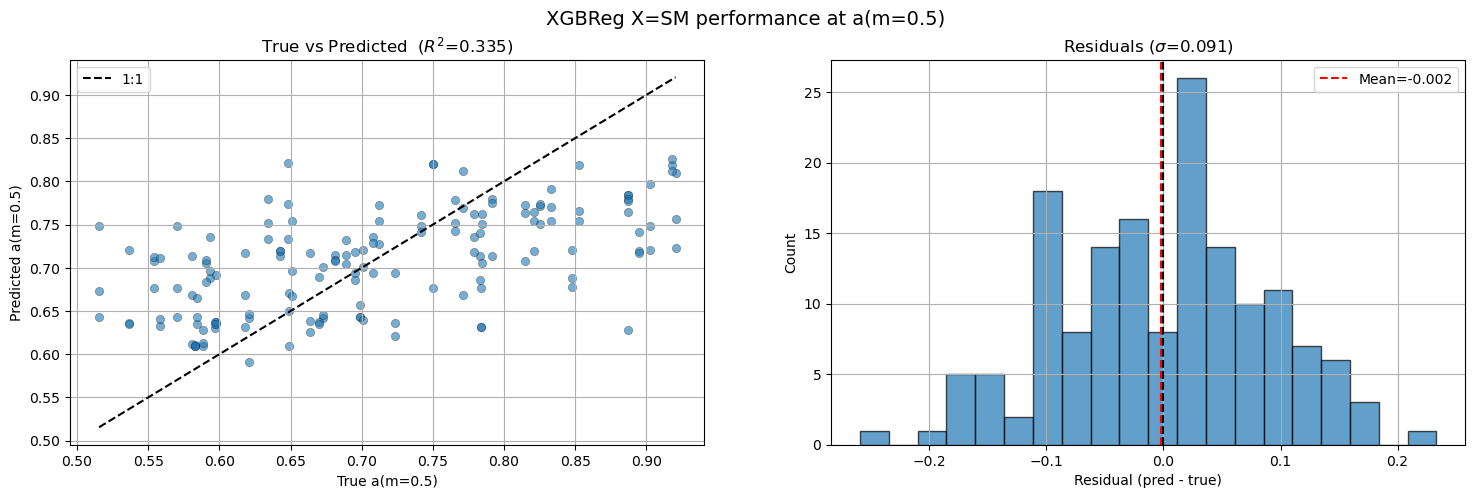

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

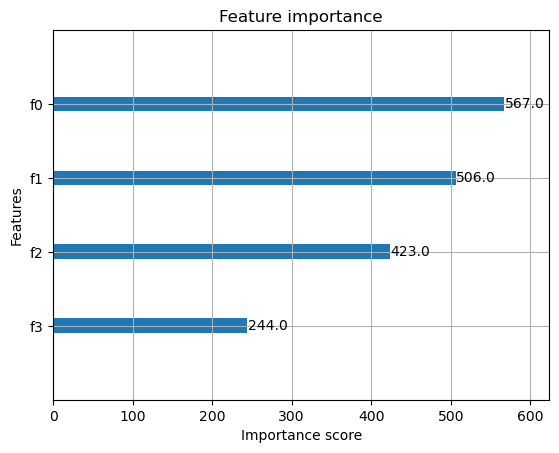

In [158]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('XGBReg X=SM performance at a(m=0.5)', fontsize=14)

# true vs predicted
axs[0].scatter(a50_test, preds, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(a50_test.min(), preds.min()), max(a50_test.max(), preds.max())]
axs[0].plot(lims, lims, 'k--', label='1:1')
axs[0].set_xlabel('True a(m=0.5)')
axs[0].set_ylabel('Predicted a(m=0.5)')
axs[0].set_title(f'True vs Predicted  ($R^2$={r2:.3f})')
axs[0].legend()
axs[0].grid()

# Residual histogram
axs[1].hist(residuals, bins=20, edgecolor='k', alpha=0.7)
axs[1].axvline(0, color='k', linestyle='--')
axs[1].axvline(residuals.mean(), color='red', linestyle='--',
               label=f'Mean={residuals.mean():.3f}')
axs[1].set_xlabel('Residual (pred - true)')
axs[1].set_ylabel('Count')
axs[1].set_title(rf'Residuals ($\sigma$={residuals.std():.3f})')
axs[1].legend()
axs[1].grid()

plt.show()

xgb.plot_importance(regressor)